In [2]:
from ultralytics import YOLO

# Load a model
model = YOLO("/content/drive/MyDrive/YOLO/yolo26n.pt")

# Train the model
train_results = model.train(
    data="/content/drive/MyDrive/YOLO/Pakistani-Number-plates.v1i.yolo26/data.yaml",  # path to dataset YAML
    epochs=30,  # number of training epochs
    imgsz=640,  # training image size
    device=0,  # device to run on, i.e. device=0 or device=0,1,2,3 or device=cpu
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/YOLO/Pakistani-Number-plates.v1i.yolo26/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fracti


image 1/1 /content/drive/MyDrive/YOLO/Pakistani-Number-plates.v1i.yolo26/test/images/DSC_0363_jpg.rf.108c80c04020f11aaf30f46108aaaf9a.jpg: 640x640 1 Number-plate, 10.9ms
Speed: 2.0ms preprocess, 10.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


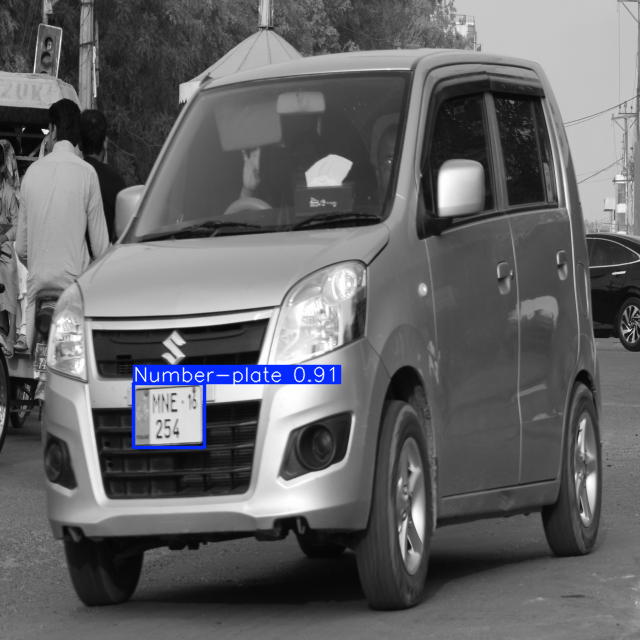

In [3]:
from ultralytics import YOLO

# Load a model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Perform object detection on an image
results = model("/content/drive/MyDrive/YOLO/Pakistani-Number-plates.v1i.yolo26/test/images/DSC_0363_jpg.rf.108c80c04020f11aaf30f46108aaaf9a.jpg", save=True)
results[0].show()


In [6]:
import cv2
import easyocr
from ultralytics import YOLO

# -----------------------------
# Load Models
# -----------------------------
model = YOLO("/content/runs/detect/train/weights/best.pt")

reader = easyocr.Reader(['en'], gpu=True)


# -----------------------------
# OCR Function
# -----------------------------
def perform_ocr(frame, box):
    """
    Perform OCR on detected bounding box.
    """
    x1, y1, x2, y2 = map(int, box)

    # Keep coordinates inside image
    h, w = frame.shape[:2]
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)

    crop = frame[y1:y2, x1:x2]

    if crop.size == 0:
        return ""

    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    results = reader.readtext(gray)

    text = ""

    for res in results:
        if len(results) == 1 or (len(res[1]) > 3 and res[2] > 0.20):
            text = res[1]

    return text


# -----------------------------
# Video
# -----------------------------
video_path = "/content/drive/MyDrive/YOLO/car.mp4"

cap = cv2.VideoCapture(video_path)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

output_path = "/content/final_output.mp4"

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))


# -----------------------------
# Detection Loop
# -----------------------------
while cap.isOpened():

    success, frame = cap.read()

    if not success:
        break

    # YOLO Detection
    results = model.predict(
        frame,
        conf=0.25,
        iou=0.45,
        verbose=False
    )

    result = results[0]

    annotated_frame = frame.copy()

    # Loop over detections
    for box in result.boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        cls = int(box.cls[0])
        conf = float(box.conf[0])

        # OCR
        ocr_text = perform_ocr(frame, (x1, y1, x2, y2))

        # If OCR fails, use class name
        label = ocr_text if ocr_text != "" else model.names[cls]

        # Draw Bounding Box
        cv2.rectangle(
            annotated_frame,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        # Draw Label
        cv2.putText(
            annotated_frame,
            label,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 255),
            2
        )

    out.write(annotated_frame)

cap.release()
out.release()

print("Video saved successfully:", output_path)

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteVideo saved successfully: /content/final_output.mp4
